In [2]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(ggstatsplot)
library(ggpubr)

library(cowplot)

# File ordering ---------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
taxa_tab <-  read.table("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/2025-11-11_vaginal_taxa_filtered.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote = '"')
head(taxa_tab)

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinobaculum massiliense,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.38593,0.00000,0.00000,0.00000
Aerococcus christensenii,0.00000,0,0.37028,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.00000,0.00000,0.23952,0.00000
Alloscardovia omnicolens,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00197,0.00000,0,1.74307,0,0.00000,0.00509,0.00000,0.71791
Anaerococcus hydrogenalis,0.00697,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00420,0,0.00319,0.00000,0.00000,0.00000
Anaerococcus lactolyticus,0.01879,0,0.00000,0,0.00000,0,0.00013,0,0,0.00035,⋯,0,0.00000,0.00062,0,0.02457,0,0.00000,0.00166,0.00000,0.00000
Anaerococcus prevotii,0.00000,0,0.00000,0,0.01267,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00989,0,0.00000,0.00000,0.00000,0.00000


In [4]:
dim(taxa_tab)

[1]  65 175

In [5]:
colnames(taxa_tab)

[1] "FF00653546" "FF00653544" "FB02825409" "FF03817116" "FF01566745"
  [6] "FF02556135" "FF03818430" "FF01571976" "FF06040450" "FF06039085"
 [11] "FF06039956" "FF06039601" "FF06039627" "FF06039861" "FF03817982"
 [16] "FF05043974" "FF05044855" "FF05044200" "FF01570382" "FF06032885"
 [21] "FF06040007" "FF06579566" "FF06580410" "FF03815366" "FF01571067"
 [26] "FF01570828" "FF02015345" "FF02015010" "FF00653065" "FF00530476"
 [31] "FF02014263" "FF02015432" "FF02015296" "FF03817626" "FF05024757"
 [36] "FF05024748" "FF08440350" "FF04761480" "FF06040483" "FF06033048"
 [41] "FF06580418" "FF00657563" "FF00653167" "FF00657544" "FF00657476"
 [46] "FF06039868" "FF06039595" "FF06039831" "FF06039830" "FF05024953"
 [51] "FF05043336" "FF04023664" "FF02557868" "FF02556105" "FF02015815"
 [56] "FF06580399" "FF04761460" "FF01570782" "FF01570777" "FF05025296"
 [61] "FF01572419" "FF05025294" "FF05043003" "FF05025300" "FF05043036"
 [66] "FF02015546" "FF02739091" "FB02846091" "FF00620268" "FF00653071"
 [71] "FF00657923" "FF02014181" "FF03817636" "FF02555999" "FF00652411"
 [76] "FF00941094" "FF02014833" "FF00651927" "FF00530460" "FF02556090"
 [81] "FF00619356" "FF00531139" "FF00530247" "FF02740674" "FF00657534"
 [86] "FF00653507" "FF00652106" "FF02015011" "FF03816378" "FF03816924"
 [91] "FF00531215" "FF00530208" "FF00530163" "FF02014805" "FF00653014"
 [96] "FF00652988" "FF00531719" "FF01572430" "FF08440357" "FF04761496"
[101] "FF08440702" "FF05044402" "FF02740612" "FF06039064" "FF06743148"
[106] "FF04761509" "FF04761505" "FF06580438" "FF00652209" "FF03818217"
[111] "FF02014450" "FF02014344" "FF05044198" "FF00653280" "FF04761535"
[116] "FF02557890" "FF03817815" "FF03817183" "FF03817972" "FF03816858"
[121] "FF03818246" "FF02557245" "FF02015423" "FF05024823" "FF02015861"
[126] "FF02013773" "FF06580149" "FF00531053" "FF03818104" "FF03815388"
[131] "FF01570606" "FF03816408" "FF00531062" "FF01572330" "FF06743126"
[136] "FF06032176" "FF00657220" "FF00653474" "FF00531725" "FF00658016"
[141] "FF06039851" "FF00657251" "FF00531455" "FF03816395" "FF01572371"
[146] "FF01572506" "FF02014735" "FF02015041" "FF02740077" "FF08440262"
[151] "FF06581586" "FF06033016" "FF00531275" "FF04760553" "FF03816396"
[156] "FF00620158" "FF06032916" "FB02825218" "FF06743139" "FF00619973"
[161] "FF00530529" "FF01570524" "FB02846907" "FF04761515" "FF00657243"
[166] "FF05044395" "FF04760422" "FF00531801" "FF08440403" "FF08440398"
[171] "FF08440427" "FF03818480" "FF08440674" "FF08440393" "FF06039070"

In [6]:
taxa_tab[,1]

[1]  0.00000  0.00000  0.00000  0.00697  0.01879  0.00000  0.00623  0.00000
 [9]  0.00000  0.01103  0.00000  0.00000  0.00000  0.00000  0.00052  0.13072
[17]  0.00957  0.02022  0.01255  0.00000  0.02617  0.00000  0.00000  0.01227
[25]  0.06033  0.10261  0.00000  0.00000  0.00000  0.00000  0.03241  0.00000
[33] 98.22154  0.00000  0.03729  0.70713  0.02794  0.00000  0.00000  0.00000
[41]  0.00000  0.04244  0.00738  0.05611  0.03749  0.00000  0.00000  0.00000
[49]  0.01996  0.13944  0.00000  0.01501  0.10168  0.00000  0.00000  0.00000
[57]  0.00000  0.00000  0.00000  0.00000  0.00805  0.00000  0.02838  0.00000
[65]  0.09977

In [7]:
row.names(taxa_tab)

[1] "Actinobaculum massiliense"           "Aerococcus christensenii"           
 [3] "Alloscardovia omnicolens"            "Anaerococcus hydrogenalis"          
 [5] "Anaerococcus lactolyticus"           "Anaerococcus prevotii"              
 [7] "Anaerococcus sp_Marseille_P3915"     "Anaerococcus tetradius"             
 [9] "Anaerococcus vaginalis"              "Atopobium deltae"                   
[11] "Campylobacter ureolyticus"           "Candida albicans"                   
[13] "Coriobacteriales bacterium_DNF00809" "Corynebacterium amycolatum"         
[15] "Corynebacterium aurimucosum"         "Corynebacterium coyleae"            
[17] "Corynebacterium pyruviciproducens"   "Corynebacterium sp_HMSC08D02"       
[19] "Corynebacterium tuscaniense"         "Dialister micraerophilus"           
[21] "Ezakiella coagulans"                 "Facklamia hominis"                  
[23] "Fannyhessea vaginae"                 "Fenollaria massiliensis"            
[25] "Finegoldia magna"                    "Gardnerella vaginalis"              
[27] "Gemella asaccharolytica"             "GGB3012 SGB4003"                    
[29] "GGB38873 SGB47522"                   "GGB39918 SGB47522"                  
[31] "GGB4277 SGB5832"                     "GGB753 SGB989"                      
[33] "Lactobacillus crispatus"             "Lactobacillus gasseri"              
[35] "Lactobacillus iners"                 "Lactobacillus jensenii"             
[37] "Lawsonella SGB3665"                  "Limosilactobacillus fermentum"      
[39] "Limosilactobacillus portuensis"      "Megasphaera genomosp_type_1"        
[41] "Megasphaera lornae"                  "Peptoniphilus coxii"                
[43] "Peptoniphilus duerdenii"             "Peptoniphilus harei"                
[45] "Peptoniphilus lacrimalis"            "Porphyromonas uenonis"              
[47] "Prevotella amnii"                    "Prevotella bivia"                   
[49] "Prevotella buccalis"                 "Prevotella colorans"                
[51] "Prevotella corporis"                 "Prevotella disiens"                 
[53] "Prevotella timonensis"               "Propionimicrobium lymphophilum"     
[55] "Sneathia sanguinegens"               "Staphylococcus epidermidis"         
[57] "Streptococcus anginosus"             "Streptococcus SGB3665"              
[59] "Tissierellia bacterium_KA00581"      "Ureaplasma parvum"                  
[61] "Varibaculum cambriense"              "Varibaculum massiliense"            
[63] "Veillonellaceae bacterium_DNF00626"  "Winkia neuii"                       
[65] "Other_taxa"

In [8]:
tail(taxa_tab)

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ureaplasma parvum,0.00000,0.05158,0.00970,0.00000,0,0,0.03087,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.06229,0.00000,0.22328,0.93376,0.00000,0.00000,0.22960
Varibaculum cambriense,0.00805,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.01344,0.00000,0.02252,0.00000,0.00000,0.00000
Varibaculum massiliense,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.04088,0.00000,0.00000,0.00000,0.00000,0.00000,0.40982,0.00000,0.00000,0.01783
Veillonellaceae bacterium_DNF00626,0.02838,0.00000,0.90706,0.00000,0,0,0.01367,0,0.00000,0.00000,⋯,0.01054,0.00000,0.00000,0.00000,0.35534,0.00131,0.00000,0.00000,0.02001,0.00000
Winkia neuii,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.12902,0.00000,0.00000,0.00000,0.00000,0.00000
Other_taxa,0.09977,0.00000,0.80965,0.00544,0,0,0.06051,0,0.08047,0.01244,⋯,1.14737,2.24081,0.00757,0.02786,0.24871,0.77614,0.71443,0.10985,0.63242,0.03292


In [9]:
combined_fp_sp_tp2 <- read.csv("/ceph//projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/2025-11-11_combined_fp_sp_tp2.csv", header = TRUE)
head(combined_fp_sp_tp2)
dim(combined_fp_sp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
3,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy
6,5239,S5fa4a39,NA,0,0,0,2018-08-30,P4de45e7,0,29,⋯,NA,NA,NA,NA,39,Induction,NA,NA,1,First pregnancy


[1]  32 567

In [10]:
# Check that all columns add up to 100
colsum_tp2 <- colSums(taxa_tab)
colsum_tp2
length(colsum_tp2)

FF00653546 FF00653544 FB02825409 FF03817116 FF01566745 FF02556135 FF03818430 
       100        100        100        100        100        100        100 
FF01571976 FF06040450 FF06039085 FF06039956 FF06039601 FF06039627 FF06039861 
       100        100        100        100        100        100        100 
FF03817982 FF05043974 FF05044855 FF05044200 FF01570382 FF06032885 FF06040007 
       100        100        100        100        100        100        100 
FF06579566 FF06580410 FF03815366 FF01571067 FF01570828 FF02015345 FF02015010 
       100        100        100        100        100        100        100 
FF00653065 FF00530476 FF02014263 FF02015432 FF02015296 FF03817626 FF05024757 
       100        100        100        100        100        100        100 
FF05024748 FF08440350 FF04761480 FF06040483 FF06033048 FF06580418 FF00657563 
       100        100        100        100        100        100        100 
FF00653167 FF00657544 FF00657476 FF06039868 FF06039595 FF06039831 FF06039830 
       100        100        100        100        100        100        100 
FF05024953 FF05043336 FF04023664 FF02557868 FF02556105 FF02015815 FF06580399 
       100        100        100        100        100        100        100 
FF04761460 FF01570782 FF01570777 FF05025296 FF01572419 FF05025294 FF05043003 
       100        100        100        100        100        100        100 
FF05025300 FF05043036 FF02015546 FF02739091 FB02846091 FF00620268 FF00653071 
       100        100        100        100        100        100        100 
FF00657923 FF02014181 FF03817636 FF02555999 FF00652411 FF00941094 FF02014833 
       100        100        100        100        100        100        100 
FF00651927 FF00530460 FF02556090 FF00619356 FF00531139 FF00530247 FF02740674 
       100        100        100        100        100        100        100 
FF00657534 FF00653507 FF00652106 FF02015011 FF03816378 FF03816924 FF00531215 
       100        100        100        100        100        100        100 
FF00530208 FF00530163 FF02014805 FF00653014 FF00652988 FF00531719 FF01572430 
       100        100        100        100        100        100        100 
FF08440357 FF04761496 FF08440702 FF05044402 FF02740612 FF06039064 FF06743148 
       100        100        100        100        100        100        100 
FF04761509 FF04761505 FF06580438 FF00652209 FF03818217 FF02014450 FF02014344 
       100        100        100        100        100        100        100 
FF05044198 FF00653280 FF04761535 FF02557890 FF03817815 FF03817183 FF03817972 
       100        100        100        100        100        100        100 
FF03816858 FF03818246 FF02557245 FF02015423 FF05024823 FF02015861 FF02013773 
       100        100        100        100        100        100        100 
FF06580149 FF00531053 FF03818104 FF03815388 FF01570606 FF03816408 FF00531062 
       100        100        100        100        100        100        100 
FF01572330 FF06743126 FF06032176 FF00657220 FF00653474 FF00531725 FF00658016 
       100        100        100        100        100        100        100 
FF06039851 FF00657251 FF00531455 FF03816395 FF01572371 FF01572506 FF02014735 
       100        100        100        100        100        100        100 
FF02015041 FF02740077 FF08440262 FF06581586 FF06033016 FF00531275 FF04760553 
       100        100        100        100        100        100        100 
FF03816396 FF00620158 FF06032916 FB02825218 FF06743139 FF00619973 FF00530529 
       100        100        100        100        100        100        100 
FF01570524 FB02846907 FF04761515 FF00657243 FF05044395 FF04760422 FF00531801 
       100        100        100        100        100        100        100 
FF08440403 FF08440398 FF08440427 FF03818480 FF08440674 FF08440393 FF06039070 
       100        100        100        100        100        100        100

[1] 175

In [11]:
# Read fp and sp metadata files to obtain barcodes, OBS $Group for FP has a SPACE at the end!!
combined_fp_sp_tp2$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[21] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[25] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"

In [12]:
fp_bc <-  combined_fp_sp_tp2 |>
  filter(Group == "First pregnancy ") |>
  pull(kit2.vaginal_sample.barcode)
print(fp_bc)
length(fp_bc)

 [1] "FF00531801" "FF02014735" "FF03816858" "FF02015861" "FF00657251"
 [6] "FF02015423" "FF00657220" "FF00531275" "FF02014450" "FF02740077"
[11] "FF02557245" "FF02014344" "FF00619973" "FB02825218" "FF00531062"
[16] "FF02740612"


[1] 16

In [13]:
sp_bc <-  combined_fp_sp_tp2 |>
  filter(Group == "Second pregnancy") |>
  pull(kit2.vaginal_sample.barcode)
print(sp_bc)
length(sp_bc)

 [1] "FF06580149" "FF08440398" "FF06032916" "FF01572330" "FF08440702"
 [6] "FF04761496" "FF06039851" "FF06743126" "FF06032176" "FF08440357"
[11] "FF04761515" "FF06743139" "FF08440262" "FF08440427" "FF06033016"
[16] "FF05024823"


[1] 16

In [14]:
# Save fp and sp in separate df 
fp_taxa <- taxa_tab[, colnames(taxa_tab) %in% fp_bc]
dim(fp_taxa) 

[1] 65 16

In [15]:
combined_fp_sp_tp2$Studienummer

[1] "S194e21b" "S1f95844" "S2b86cc0" "S39fe1d7" "S7e4a963" "S5fa4a39"
 [7] "S5b98b6c" "S2b3865e" "S719b21e" "S9026714" "S97574f9" "S9cdfd5a"
[13] "S257a907" "Scb66cdd" "Sca94a0f" "Sf92b278" "S159f9c8" "S0e78496"
[19] "S3cac7b0" "S3db7da6" "S424fd61" "S4de45e7" "S0332ad6" "S62ea0b2"
[25] "S02c5e39" "S7ece52e" "Sb242462" "Sc56fd3c" "Sbe289c8" "Sc77a35c"
[31] "S034bf15" "Sdab1897"

In [16]:
sp_taxa <- taxa_tab[, colnames(taxa_tab) %in% sp_bc]
dim(sp_taxa) 

[1] 65 16

# Alpha Diversity -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Shannon--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [17]:
fp_shan_tp2 <- apply(fp_taxa, 2, diversity, index = "shannon")
fp_shan_tp2

FF02740612 FF02014450 FF02014344 FF03816858 FF02557245 FF02015423 FF02015861 
0.76653316 0.03229818 0.66269445 0.15667443 0.47500754 0.17692788 1.34955333 
FF00531062 FF00657220 FF00657251 FF02014735 FF02740077 FF00531275 FB02825218 
0.87444919 1.19743643 1.81930697 0.06640487 0.14184989 0.03453471 0.90104803 
FF00619973 FF00531801 
1.26489770 0.02133239

In [18]:
summary(fp_shan_tp2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02133 0.12299 0.56885 0.62131 0.97515 1.81931 

In [19]:
sp_shan_tp2 <- apply(sp_taxa, 2, diversity, index = "shannon")
sp_shan_tp2  

FF08440357 FF04761496 FF08440702 FF05024823 FF06580149 FF01572330 FF06743126 
0.06952553 1.31874981 0.73471326 0.69651175 0.17090115 0.69326607 0.57339508 
FF06032176 FF06039851 FF08440262 FF06033016 FF06032916 FF06743139 FF04761515 
0.85778958 0.85705265 0.53619011 0.86597641 0.02682185 0.59116253 0.37445989 
FF08440398 FF08440427 
0.64886963 0.25374662

In [20]:
summary(sp_shan_tp2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02682 0.34428 0.62002 0.57932 0.76530 1.31875 

In [21]:
# Save shannon index into one df
df_shannon <- data.frame(Shannon = c(fp_shan_tp2, sp_shan_tp2), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_shan_tp2), length(sp_shan_tp2))))
head(df_shannon)

,Shannon,Group
,<dbl>,<chr>
FF02740612,0.76653316,Nulliparous
FF02014450,0.03229818,Nulliparous
FF02014344,0.66269445,Nulliparous
FF03816858,0.15667443,Nulliparous
FF02557245,0.47500754,Nulliparous
FF02015423,0.17692788,Nulliparous


In [22]:
# Check that numeric
class(df_shannon$Shannon)

[1] "numeric"

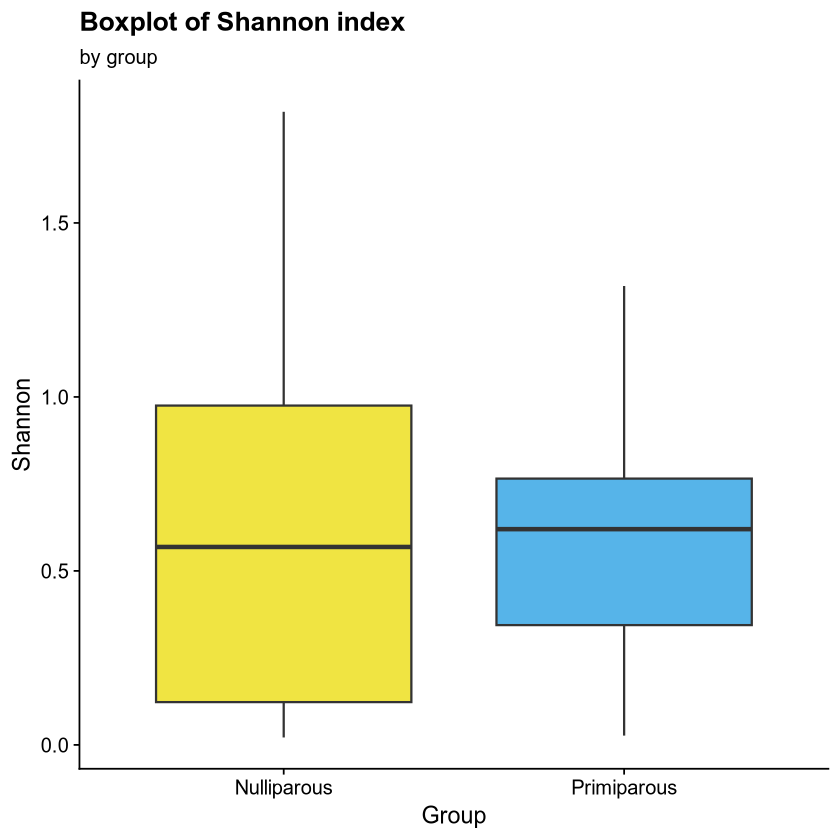

In [23]:
clr_tp2 <- c("Nulliparous" = "#F0E442" , "Primiparous" = "#56B4E9")

# Boxplot
df_shannon |> ggplot(aes(x = Group, y = Shannon, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Shannon",
    title = "Boxplot of Shannon index", 
    subtitle = "by group"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

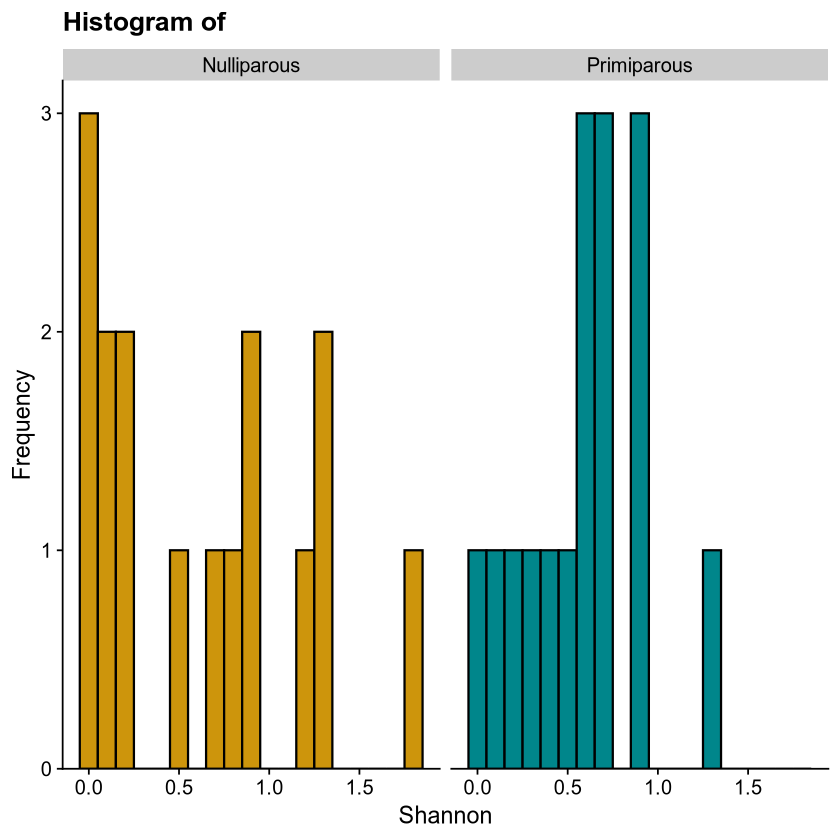

In [24]:
# Histogram
df_shannon |> ggplot(aes(x = Shannon, fill = Group)) +
geom_histogram(binwidth = 0.1, position = "identity", col = "black") + 
scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
labs(
    x = "Shannon",
    y = "Frequency",
    title = "Histogram of "
) +
scale_y_continuous(
    expand = expansion(mult = c(0, 0.05))
  ) + 
theme_half_open() +
facet_wrap(~Group) +
theme(legend.position = "none") 

In [25]:
# after this Primiparous == NA
df_shannon_1 <- df_shannon |>
  rownames_to_column(var = "Sample_ID")
head(df_shannon_1)

,Sample_ID,Shannon,Group
,<chr>,<dbl>,<chr>
1,FF02740612,0.76653316,Nulliparous
2,FF02014450,0.03229818,Nulliparous
3,FF02014344,0.66269445,Nulliparous
4,FF03816858,0.15667443,Nulliparous
5,FF02557245,0.47500754,Nulliparous
6,FF02015423,0.17692788,Nulliparous


In [26]:
df_wide_shan <- pivot_wider(df_shannon_1, names_from = Group, values_from = Shannon)

In [27]:
# Extrac personal numbers for barcodes and add new column with pn to df_shannon_1
pn <- combined_fp_sp_tp2 |>
  filter(kit2.vaginal_sample.barcode %in% df_shannon_1$Sample_ID) %>% pull(Q1_Personnummer)
df_shannon_1$Personal_number <- pn
head(df_shannon_1)

,Sample_ID,Shannon,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,FF02740612,0.76653316,Nulliparous,P159f9c8
2,FF02014450,0.03229818,Nulliparous,P1f95844
3,FF02014344,0.66269445,Nulliparous,P3cac7b0
4,FF03816858,0.15667443,Nulliparous,P3db7da6
5,FF02557245,0.47500754,Nulliparous,P424fd61
6,FF02015423,0.17692788,Nulliparous,P4de45e7


In [28]:
which(duplicated(df_shannon_1$Personal_number) == TRUE)
length(which(duplicated(df_shannon_1$Personal_number) == TRUE))

[1] 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32

[1] 16

In [29]:
# Write to file, name with no space between, without barcodes
#write.csv(df_shannon_1, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_shannon", ".csv"), row.names = FALSE)

In [30]:
# Check that there are correct num of pn
length(which(duplicated(df_shannon_1$Personal_number) == TRUE))

[1] 16

In [31]:
shannon_wide <- df_shannon_1 |>
  select(Personal_number, Group, Shannon) |>
  pivot_wider(
    names_from = Group,
    values_from = Shannon
    )
head(shannon_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.76653316,0.06952553
P1f95844,0.03229818,1.31874981
P3cac7b0,0.66269445,0.73471326
P3db7da6,0.15667443,0.69651175
P424fd61,0.47500754,0.17090115
P4de45e7,0.17692788,0.69326607


In [32]:
# Calculate the difference between groups and perform distribution test 
shannon_wide$difference <- shannon_wide$Primiparous - shannon_wide$Nulliparous
shapiro.test(shannon_wide$difference)


	Shapiro-Wilk normality test

data:  shannon_wide$difference
W = 0.986, p-value = 0.9938


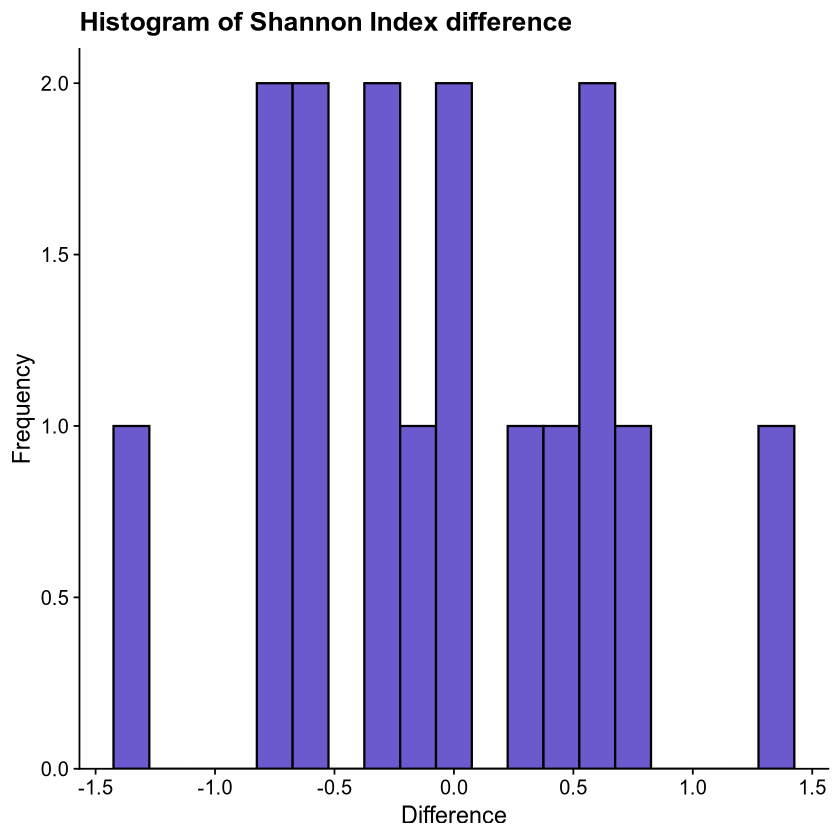

In [33]:
# View the distribution
shannon_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.15, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Shannon Index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [34]:
t.test(Pair(Nulliparous, Primiparous) ~ 1,data = shannon_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 0.24933, df = 15, p-value = 0.8065
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.3169566  0.4009337
sample estimates:
mean difference 
     0.04198858 


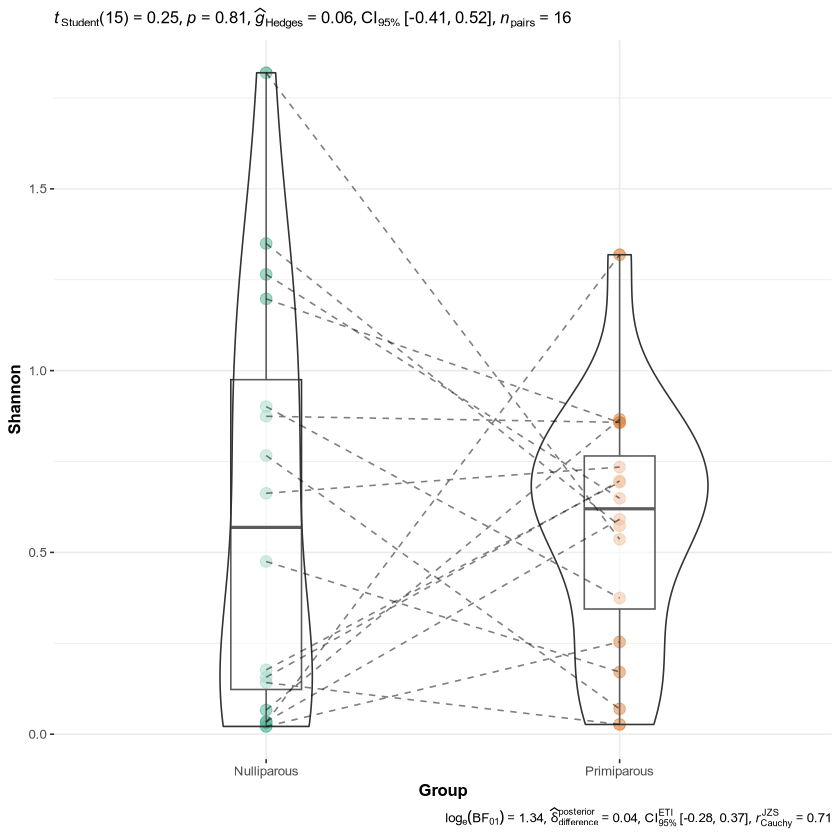

In [35]:
ggwithinstats( # paired samples
  data = df_shannon_1,
  x = Group,
  y = Shannon,
  centrality.plotting = FALSE # remove median
)

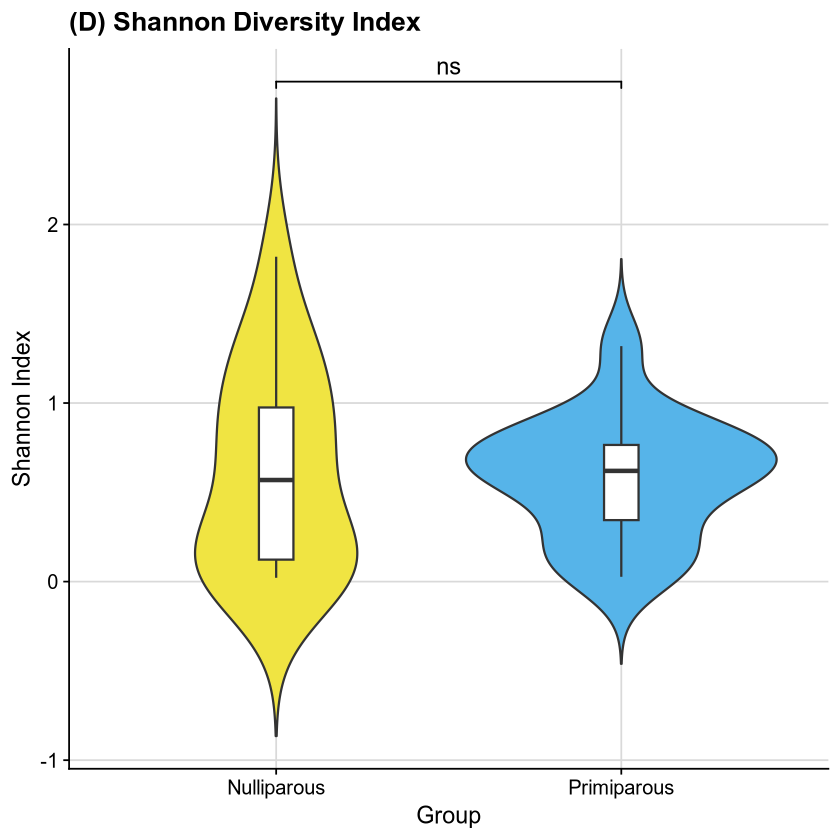

In [101]:
# Shannon Diversity Index Plot
plot_shan <- ggplot(df_shannon, aes(x = Group, y = Shannon, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(title = "(D) Shannon Diversity Index", x = "Group", y = "Shannon Index") +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none") +
     geom_signif(
    annotations = "ns",                 
    y_position = 2.8,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5
  )
plot_shan

### Species richness--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [37]:
# Count species num 
# 2 for columns, column = sample
fp_sr <- apply(fp_taxa, 2, specnumber)
head(fp_sr)

FF02740612 FF02014450 FF02014344 FF03816858 FF02557245 FF02015423 
        16         15         11          6          5         11

In [38]:
sp_sr <- apply(sp_taxa, 2, specnumber)
head(sp_sr)

FF08440357 FF04761496 FF08440702 FF05024823 FF06580149 FF01572330 
        11         19         22          6          6          7

In [39]:
summary(fp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    9.75   14.00   16.19   22.75   34.00 

In [40]:
summary(sp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3.00    6.00   12.00   14.62   22.00   34.00 

In [41]:
# New df including richness
df_richness <-  data.frame(Species_richness = c(fp_sr, sp_sr), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_sr), length(sp_sr))))
head(df_richness)

,Species_richness,Group
,<int>,<chr>
FF02740612,16,Nulliparous
FF02014450,15,Nulliparous
FF02014344,11,Nulliparous
FF03816858,6,Nulliparous
FF02557245,5,Nulliparous
FF02015423,11,Nulliparous


In [42]:
# Count num of participants
df_richness |> filter(Group == "Nulliparous") |> count()

n
<int>
16


In [43]:
df_richness |> filter(Group == "Primiparous") |> count()

n
<int>
16


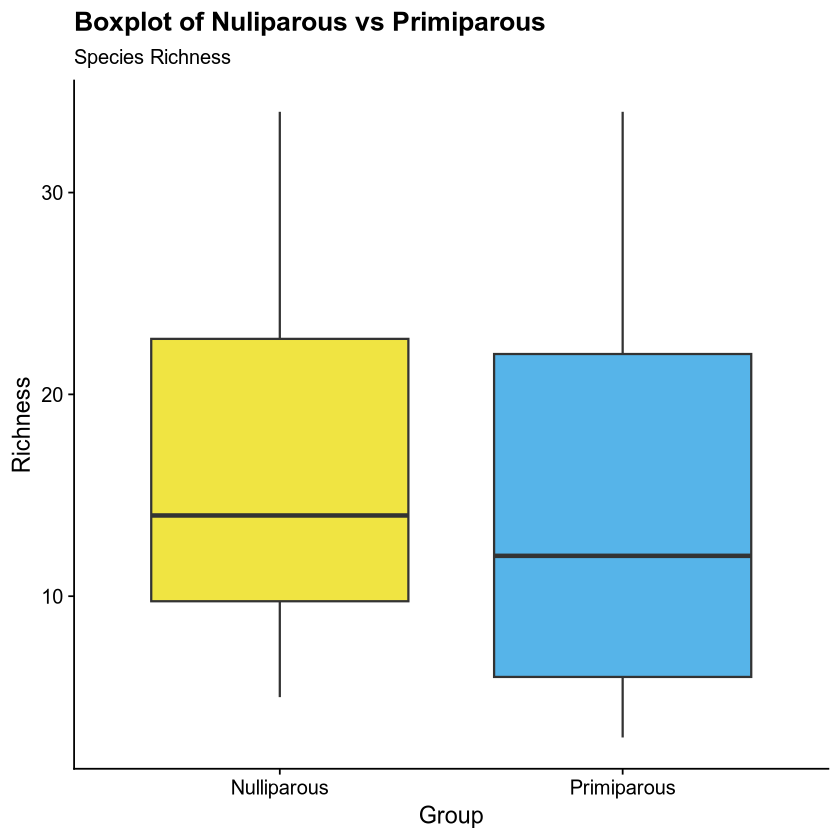

In [44]:
# Boxplot of species richness
df_richness |>
  ggplot(aes(x = Group, y = Species_richness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Richness",
    title = "Boxplot of Nuliparous vs Primiparous",
    subtitle = "Species Richness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") 

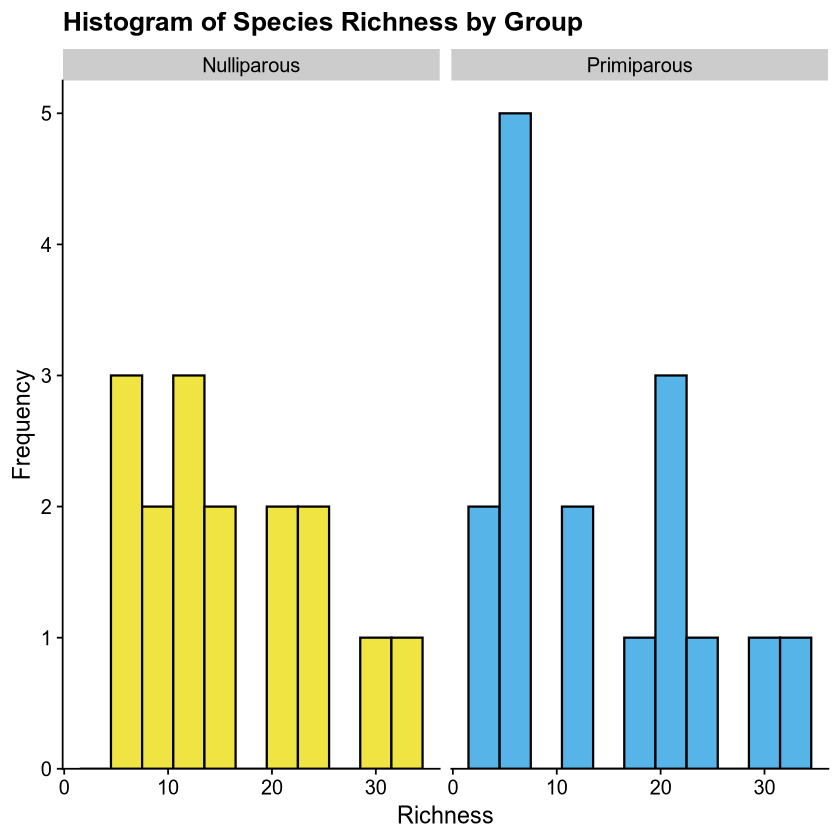

In [45]:
# Histogram of species richness
df_richness |> ggplot(aes(x = Species_richness, fill = Group)) +
  geom_histogram(binwidth = 3, position = "identity", col = "black") +
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "Histogram of Species Richness by Group",
    x = "Richness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [46]:
# Calculate difference for Shapiro test
df_richness_1 <- df_richness |>
  rownames_to_column(var = "Sample_ID")
head(df_richness_1)

,Sample_ID,Species_richness,Group
,<chr>,<int>,<chr>
1,FF02740612,16,Nulliparous
2,FF02014450,15,Nulliparous
3,FF02014344,11,Nulliparous
4,FF03816858,6,Nulliparous
5,FF02557245,5,Nulliparous
6,FF02015423,11,Nulliparous


In [47]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_richness <- combined_fp_sp_tp2 |>
  filter(kit2.vaginal_sample.barcode %in% df_richness_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_richness_1$Personal_number <- pn_richness
df_richness_1$Personal_number

[1] "P159f9c8" "P1f95844" "P3cac7b0" "P3db7da6" "P424fd61" "P4de45e7"
 [7] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P97574f9" "P9cdfd5a"
[13] "Pbe289c8" "Pc77a35c" "Pca94a0f" "Pdab1897" "P159f9c8" "P1f95844"
[19] "P3cac7b0" "P3db7da6" "P424fd61" "P4de45e7" "P5b98b6c" "P62ea0b2"
[25] "P719b21e" "P7ece52e" "P97574f9" "P9cdfd5a" "Pbe289c8" "Pc77a35c"
[31] "Pca94a0f" "Pdab1897"

In [48]:
length(df_richness_1$Personal_number)

[1] 32

In [49]:
which(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32

In [50]:
# Write to file, name with no space between, without barcodes
#write.csv(df_richness_1, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_richness", ".csv"), row.names = FALSE)

In [51]:
length(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 32

In [52]:
richness_wide <- df_richness_1 |>
  select(Personal_number, Group, Species_richness) |>
  pivot_wider(
             names_from = Group,
             values_from = Species_richness
           )
head(richness_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<int>,<int>
P159f9c8,16,11
P1f95844,15,19
P3cac7b0,11,22
P3db7da6,6,6
P424fd61,5,6
P4de45e7,11,7


In [53]:
# Test data distribution
richness_wide$difference <- richness_wide$Primiparous - richness_wide$Nulliparous
shapiro.test(richness_wide$difference)


	Shapiro-Wilk normality test

data:  richness_wide$difference
W = 0.96299, p-value = 0.7163


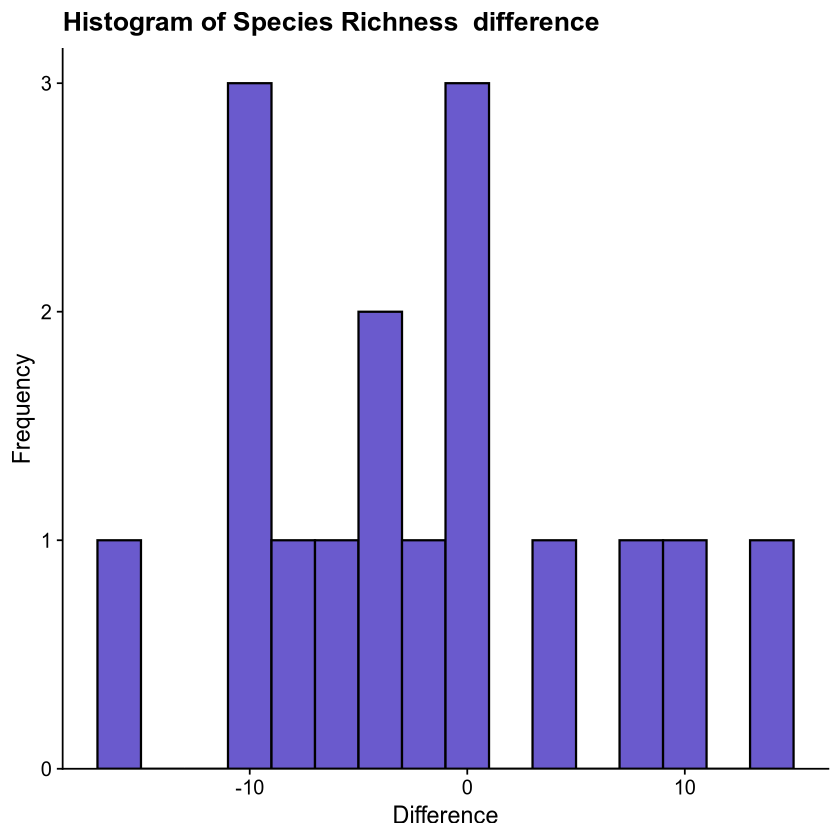

In [54]:
# Data distribution visualization
richness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 2, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Richness  difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [55]:
t.test(Pair(Nulliparous, Primiparous) ~ 1, data = richness_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 0.76019, df = 15, p-value = 0.4589
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -2.818518  5.943518
sample estimates:
mean difference 
         1.5625 


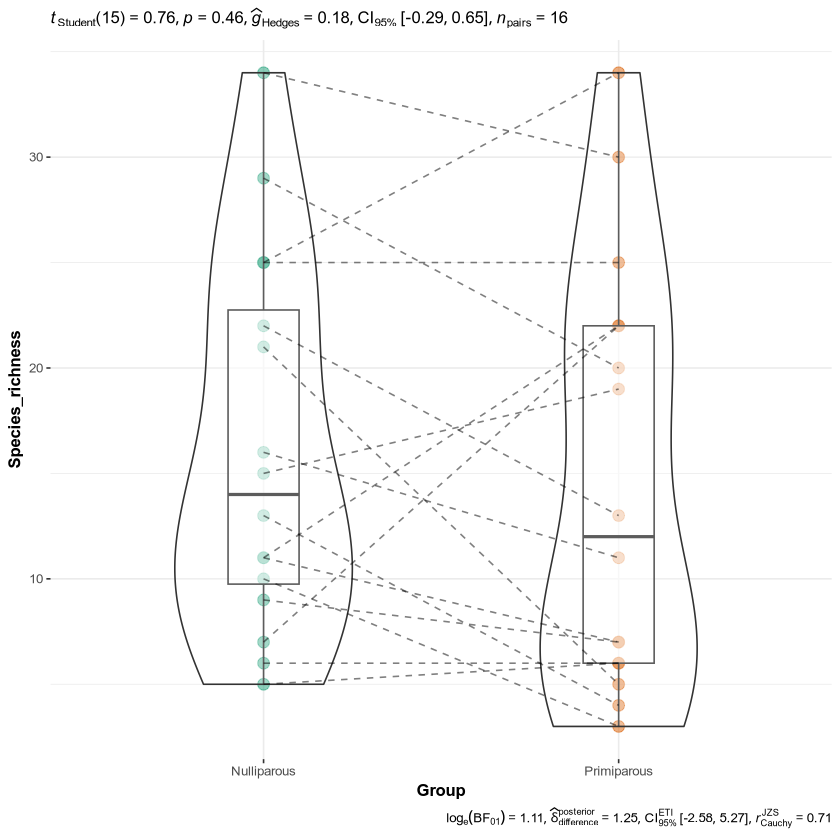

In [56]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_richness,
  x = Group,
  y = Species_richness,
  centrality.plotting = FALSE # remove median
)

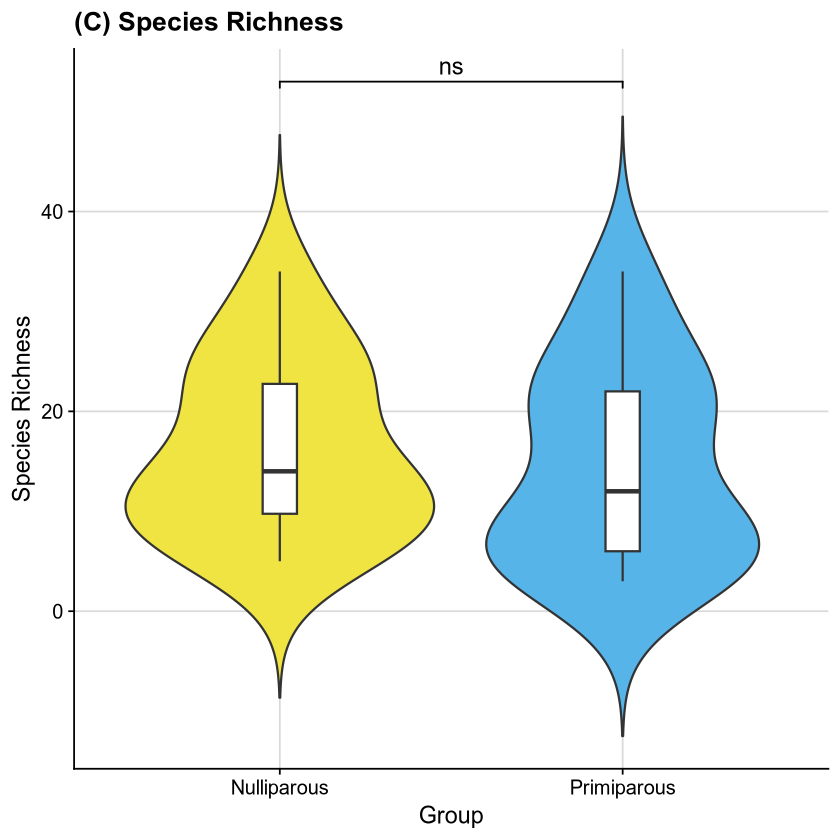

In [97]:
# Shannon Diversity Index Plot
plot_richness <- ggplot(df_richness, aes(x = Group, y = Species_richness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "(C) Species Richness", 
    x = "Group", 
    y = "Species Richness"
    ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none") +
        geom_signif(
    annotations = "ns",                 
    y_position = 53,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5
  )
plot_richness

### Evenness ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [58]:
# Fp
case_pie_small <- fp_shan_tp2/log(fp_sr)
case_pie_small

FF02740612  FF02014450  FF02014344  FF03816858  FF02557245  FF02015423 
0.276468396 0.011926729 0.276365053 0.087441666 0.295138776 0.073784659 
 FF02015861  FF00531062  FF00657220  FF00657251  FF02014735  FF02740077 
0.443272585 0.271662914 0.339567216 0.540287240 0.021483002 0.055303194 
 FF00531275  FB02825218  FF00619973  FF00531801 
0.014998233 0.463047088 0.392962566 0.009708788

In [59]:
summary(case_pie_small)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.009709 0.046848 0.274014 0.223339 0.352916 0.540287 

In [60]:
# Sp
control_pie <- sp_shan_tp2/log(sp_sr)
control_pie

FF08440357 FF04761496 FF08440702 FF05024823 FF06580149 FF01572330 FF06743126 
0.02899440 0.44787812 0.23769109 0.38873061 0.09538175 0.35626829 0.35627039 
FF06032176 FF06039851 FF08440262 FF06033016 FF06032916 FF06743139 FF04761515 
0.26648732 0.25198557 0.17898466 0.33761930 0.01934787 0.53809932 0.12114356 
FF08440398 FF08440427 
0.18400547 0.13039997

In [61]:
summary(control_pie)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.01935 0.12809 0.24484 0.24621 0.35627 0.53810 

In [62]:
df_evenness <-  data.frame(Evenness = c(case_pie_small, control_pie), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(case_pie_small), length(control_pie))))
head(df_evenness)
class(df_evenness$Evenness)

,Evenness,Group
,<dbl>,<chr>
FF02740612,0.27646840,Nulliparous
FF02014450,0.01192673,Nulliparous
FF02014344,0.27636505,Nulliparous
FF03816858,0.08744167,Nulliparous
FF02557245,0.29513878,Nulliparous
FF02015423,0.07378466,Nulliparous


[1] "numeric"

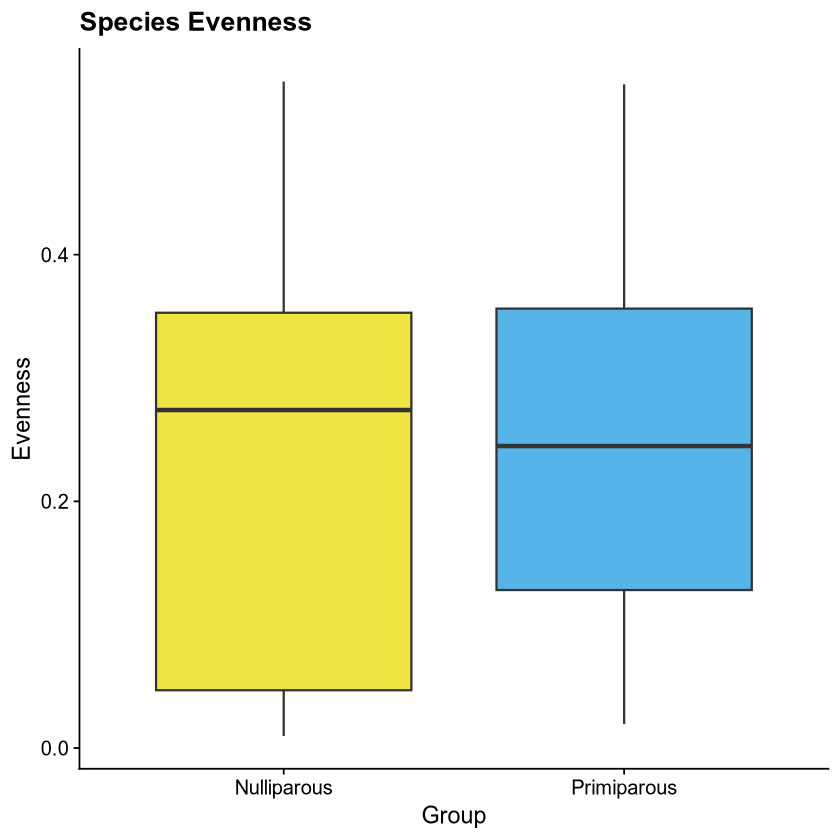

In [63]:
# Boxplot of evenness
 df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Evenness",
    title = "Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

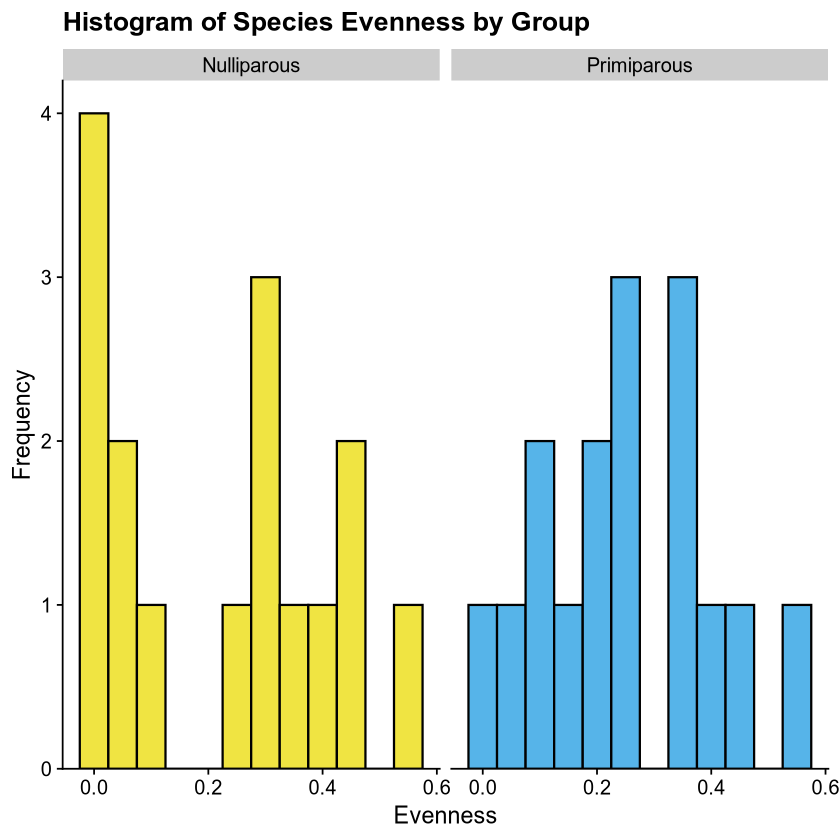

In [64]:
# Histogram of evenness
df_evenness |> ggplot(aes(x = Evenness, fill = Group)) + 
  geom_histogram(binwidth = 0.05, position = "identity", col = "black") + 
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "Histogram of Species Evenness by Group",
    x = "Evenness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [65]:
df_evenness <- df_evenness |>
  rownames_to_column(var = "Sample_ID")
head(df_evenness)

,Sample_ID,Evenness,Group
,<chr>,<dbl>,<chr>
1,FF02740612,0.27646840,Nulliparous
2,FF02014450,0.01192673,Nulliparous
3,FF02014344,0.27636505,Nulliparous
4,FF03816858,0.08744167,Nulliparous
5,FF02557245,0.29513878,Nulliparous
6,FF02015423,0.07378466,Nulliparous


In [66]:
# Find and extract pn
pn_evenness <- combined_fp_sp_tp2 |>
  filter(kit2.vaginal_sample.barcode %in% df_evenness$Sample_ID) |> pull(Q1_Personnummer)
pn_evenness

[1] "P159f9c8" "P1f95844" "P3cac7b0" "P3db7da6" "P424fd61" "P4de45e7"
 [7] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P97574f9" "P9cdfd5a"
[13] "Pbe289c8" "Pc77a35c" "Pca94a0f" "Pdab1897" "P159f9c8" "P1f95844"
[19] "P3cac7b0" "P3db7da6" "P424fd61" "P4de45e7" "P5b98b6c" "P62ea0b2"
[25] "P719b21e" "P7ece52e" "P97574f9" "P9cdfd5a" "Pbe289c8" "Pc77a35c"
[31] "Pca94a0f" "Pdab1897"

In [67]:
df_evenness$Personal_number <- pn_evenness
head(df_evenness)

,Sample_ID,Evenness,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,FF02740612,0.27646840,Nulliparous,P159f9c8
2,FF02014450,0.01192673,Nulliparous,P1f95844
3,FF02014344,0.27636505,Nulliparous,P3cac7b0
4,FF03816858,0.08744167,Nulliparous,P3db7da6
5,FF02557245,0.29513878,Nulliparous,P424fd61
6,FF02015423,0.07378466,Nulliparous,P4de45e7


In [68]:
# Write to file, name with no space between, without barcodes
#write.csv(df_evenness, file = paste0("/ceph//projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_evenness", ".csv"), row.names = FALSE)

In [69]:
evenness_wide <- df_evenness |>
  select(Personal_number, Group, Evenness) |>
  pivot_wider(
    names_from = Group,
    values_from = Evenness
  )
head(evenness_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.27646840,0.02899440
P1f95844,0.01192673,0.44787812
P3cac7b0,0.27636505,0.23769109
P3db7da6,0.08744167,0.38873061
P424fd61,0.29513878,0.09538175
P4de45e7,0.07378466,0.35626829


In [70]:
evenness_wide$difference <- evenness_wide$Primiparous - evenness_wide$Nulliparous
shapiro.test(evenness_wide$difference)


	Shapiro-Wilk normality test

data:  evenness_wide$difference
W = 0.93955, p-value = 0.3435


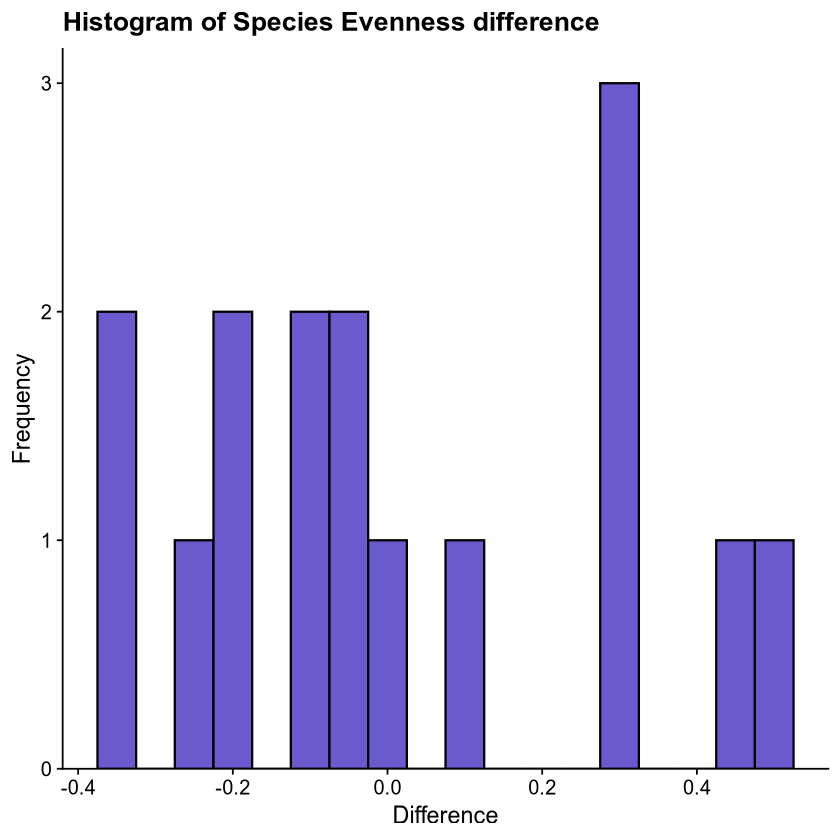

In [71]:
# Visualize data distribution
evenness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.05, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Evenness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

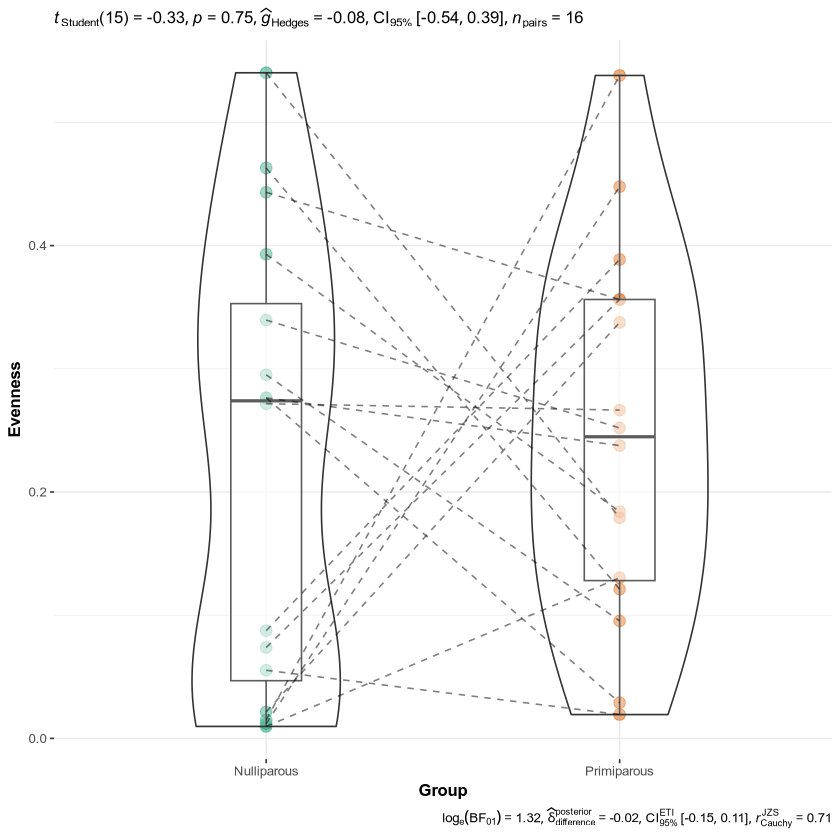

In [72]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_evenness,
  x = Group,
  y = Evenness,
  centrality.plotting = FALSE # remove median
)

In [73]:
test_evenness <- t.test(Pair(Nulliparous, Primiparous) ~1, data = evenness_wide)
test_evenness
evenness_p <- test_evenness$p.value


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.33024, df = 15, p-value = 0.7458
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.1704550  0.1247213
sample estimates:
mean difference 
    -0.02286685 


In [74]:
evenness_p

[1] 0.7457857

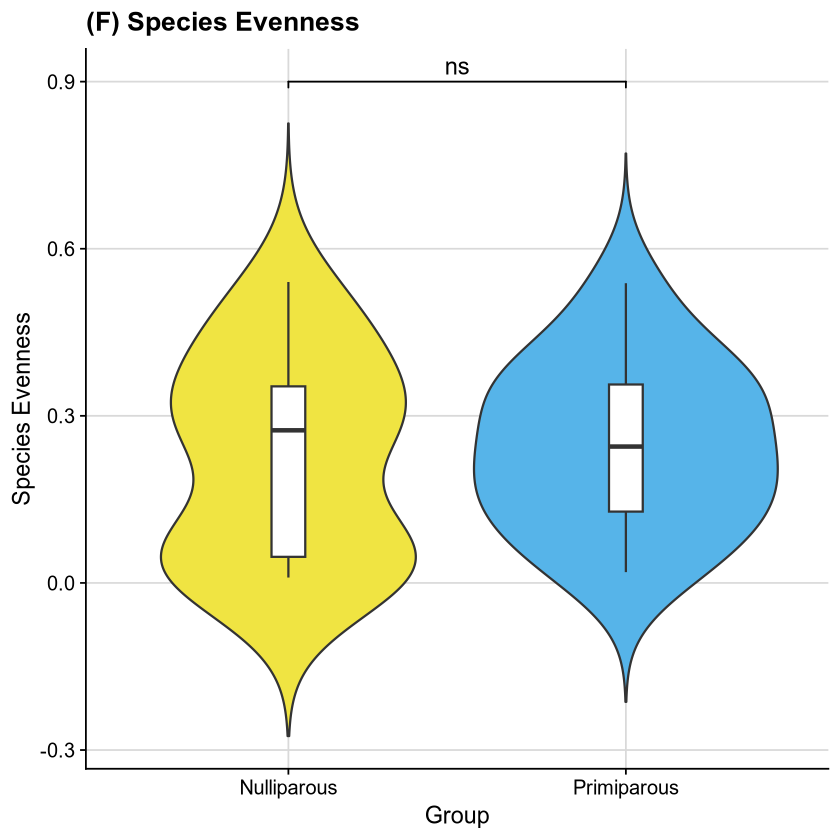

In [95]:
# Violin plots of evenness
plot_evenness <- df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Species Evenness",
    title = "(F) Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  theme(legend.position = "none") +
    geom_signif(
    annotations = "ns",                 
    y_position = 0.9,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5
  )
plot_evenness

## Simpson's index---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [76]:
# 2 for columns, column = sample
fp_simpson_tp2 <- apply(fp_taxa, 2, diversity, index = "simpson")
head(fp_simpson_tp2)

FF02740612  FF02014450  FF02014344  FF03816858  FF02557245  FF02015423 
0.509929830 0.007213459 0.407696384 0.058367645 0.248208589 0.059153140

In [77]:
sp_simpson_tp2 <- apply(sp_taxa, 2, diversity, index = "simpson")
head(sp_simpson_tp2)

FF08440357 FF04761496 FF08440702 FF05024823 FF06580149 FF01572330 
0.01933816 0.63729338 0.33232714 0.43680777 0.06697681 0.45691030

In [78]:
df_simpson_tp2 <-  data.frame(Simpson = c(fp_simpson_tp2, sp_simpson_tp2), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_simpson_tp2), length(sp_simpson_tp2))))
head(df_simpson_tp2)
class(df_simpson_tp2$Simpson)

,Simpson,Group
,<dbl>,<chr>
FF02740612,0.509929830,Nulliparous
FF02014450,0.007213459,Nulliparous
FF02014344,0.407696384,Nulliparous
FF03816858,0.058367645,Nulliparous
FF02557245,0.248208589,Nulliparous
FF02015423,0.059153140,Nulliparous


[1] "numeric"

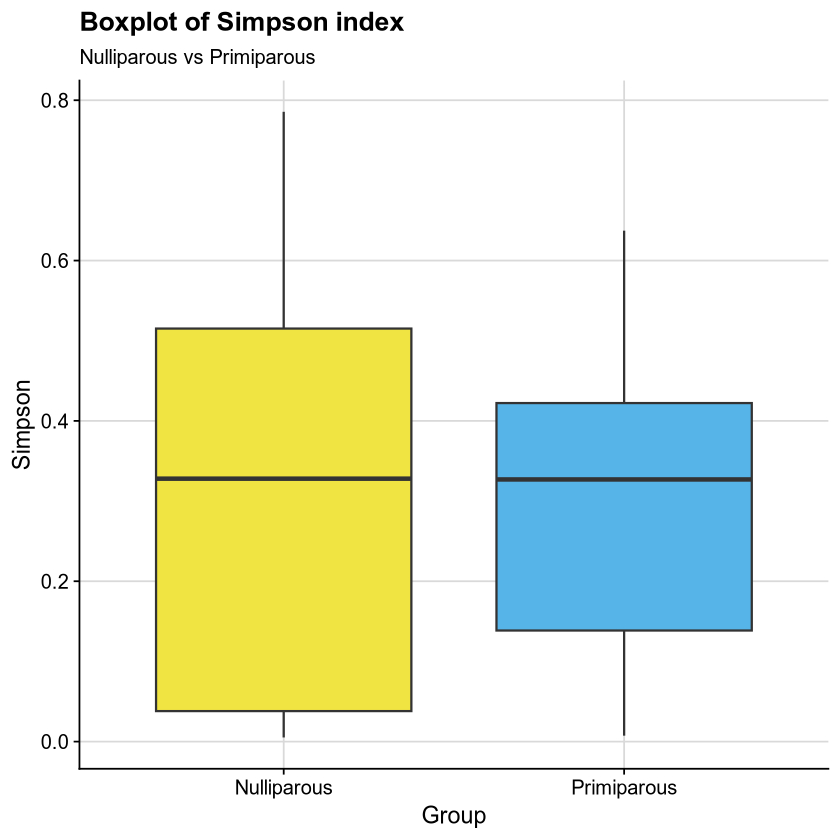

In [79]:
# Boxplot of Simpson index
df_simpson_tp2 |> 
  ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "Boxplot of Simpson index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Simpson",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

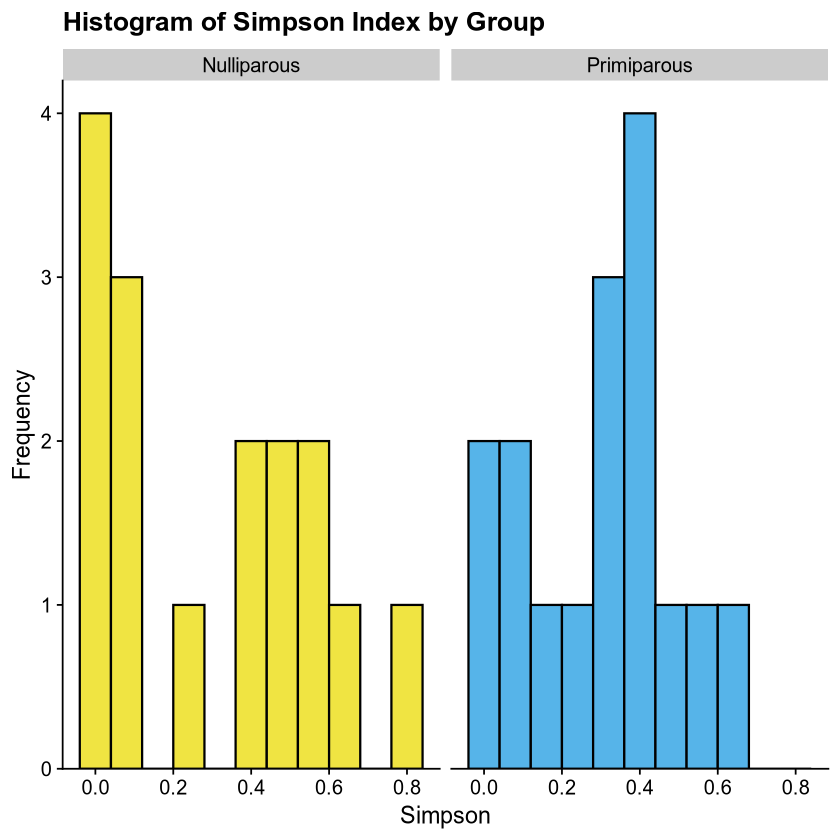

In [80]:
# Histogram of simpson index
df_simpson_tp2 |> ggplot(aes(x = Simpson, fill = Group)) + 
  geom_histogram(binwidth = 0.08, position = "identity", col = "black") + 
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "Histogram of Simpson Index by Group",
    x = "Simpson",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [81]:
df_simpson_1 <- df_simpson_tp2 |>
  rownames_to_column(var = "Sample_ID")
head(df_simpson_1)

,Sample_ID,Simpson,Group
,<chr>,<dbl>,<chr>
1,FF02740612,0.509929830,Nulliparous
2,FF02014450,0.007213459,Nulliparous
3,FF02014344,0.407696384,Nulliparous
4,FF03816858,0.058367645,Nulliparous
5,FF02557245,0.248208589,Nulliparous
6,FF02015423,0.059153140,Nulliparous


In [82]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_simpson <- combined_fp_sp_tp2 |>
  filter(kit2.vaginal_sample.barcode %in% df_simpson_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_simpson_1$Personal_number <- pn_simpson
df_simpson_1$Personal_number

[1] "P159f9c8" "P1f95844" "P3cac7b0" "P3db7da6" "P424fd61" "P4de45e7"
 [7] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P97574f9" "P9cdfd5a"
[13] "Pbe289c8" "Pc77a35c" "Pca94a0f" "Pdab1897" "P159f9c8" "P1f95844"
[19] "P3cac7b0" "P3db7da6" "P424fd61" "P4de45e7" "P5b98b6c" "P62ea0b2"
[25] "P719b21e" "P7ece52e" "P97574f9" "P9cdfd5a" "Pbe289c8" "Pc77a35c"
[31] "Pca94a0f" "Pdab1897"

In [83]:
length(which(duplicated(df_simpson_1$Personal_number) == TRUE))

[1] 16

In [84]:
#write.csv(df_simpson_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_simpson", ".csv"), row.names = FALSE)

In [85]:
simpson_wide <- df_simpson_1 |>
  select(Personal_number, Group, Simpson) |>
  pivot_wider(
             names_from = Group,
             values_from = Simpson
           )
head(simpson_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.509929830,0.01933816
P1f95844,0.007213459,0.63729338
P3cac7b0,0.407696384,0.33232714
P3db7da6,0.058367645,0.43680777
P424fd61,0.248208589,0.06697681
P4de45e7,0.059153140,0.45691030


In [86]:
# Test data distribution
simpson_wide$difference <- simpson_wide$Primiparous - simpson_wide$Nulliparous
shapiro.test(simpson_wide$difference)


	Shapiro-Wilk normality test

data:  simpson_wide$difference
W = 0.93415, p-value = 0.2834


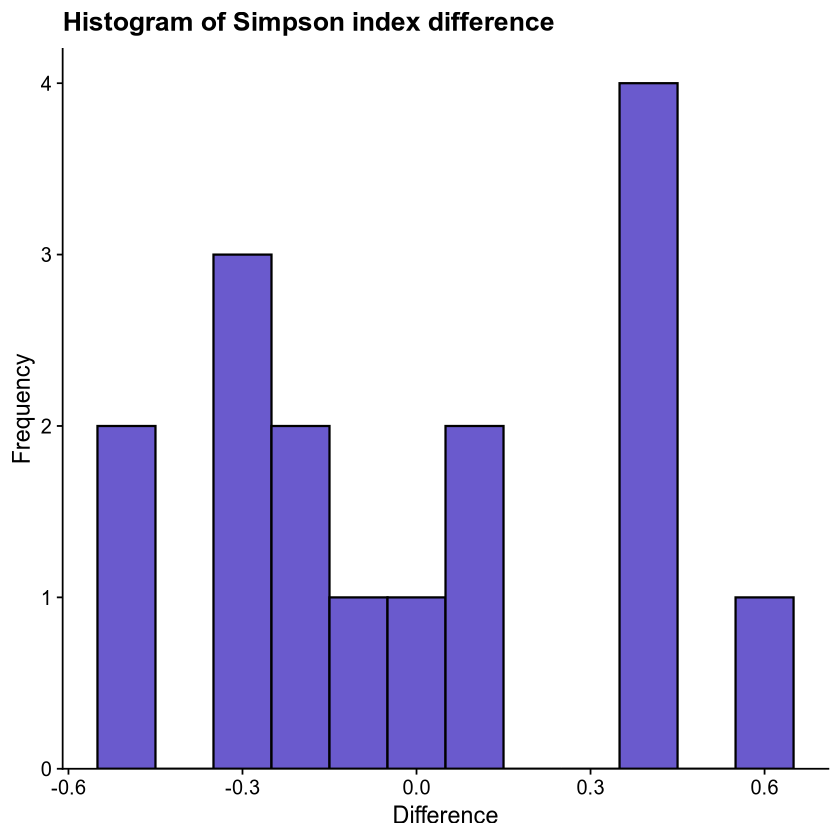

In [87]:
# Data distribution visualization
simpson_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.1, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Simpson index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [88]:
test_simpson <- t.test(Pair(Nulliparous, Primiparous) ~1, data = simpson_wide)
test_simpson


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.0019296, df = 15, p-value = 0.9985
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.1873796  0.1870407
sample estimates:
mean difference 
  -0.0001694779 


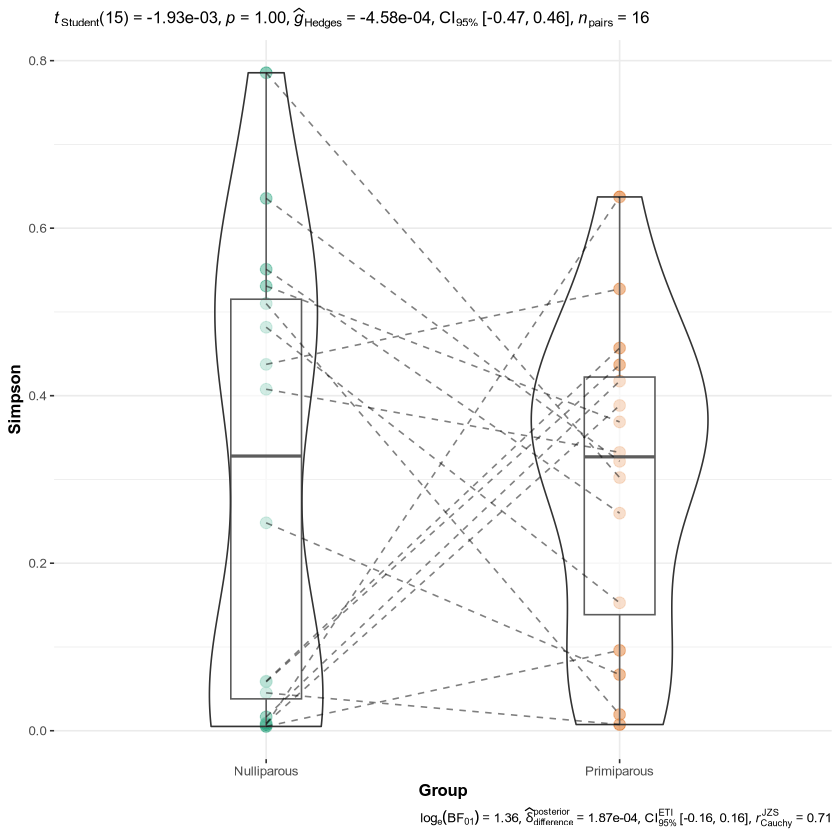

In [89]:
ggwithinstats( # paired samples
  data = df_simpson_1,
  x = Group,
  y = Simpson,
  centrality.plotting = FALSE # remove median
)

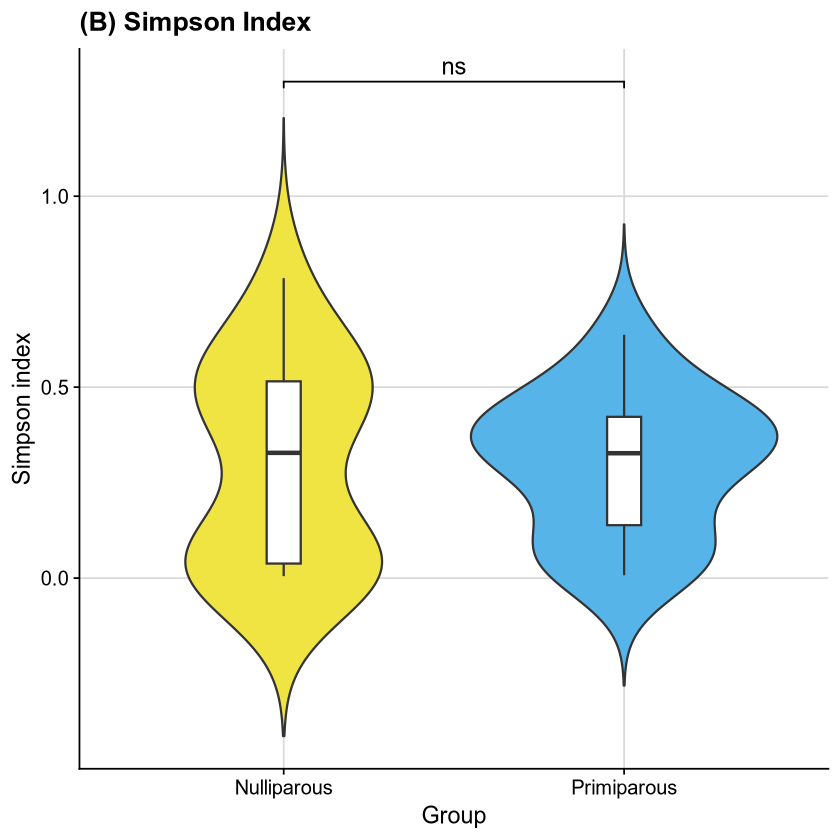

In [94]:
# Violin plots
plot_simpson <- df_simpson_1 |> ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Simpson index",
    title = "(B) Simpson Index"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  theme(legend.position = "none") +
    geom_signif(
    annotations = "ns",                 
    y_position = 1.3,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5
  )
plot_simpson

# Plots~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [102]:
# remove legends so only one remains
plot_shannon_nl <- plot_shan +  guides(fill = "none", color = "none") 
plot_richness_nl <- plot_richness +  guides(fill = "none", color = "none") 

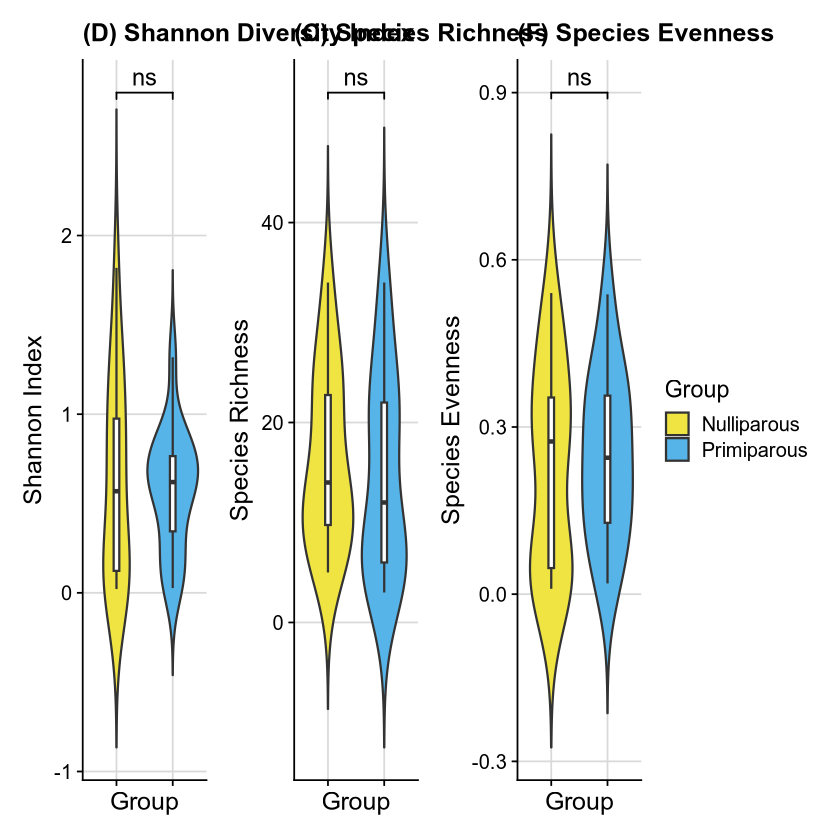

In [106]:
final_plot <-
  ( plot_shannon_nl | plot_richness_nl | plot_evenness) &
  theme_half_open() &
  background_grid() &
  theme(
    axis.text.x = element_blank(), # Remove Nulliparous etc
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )

final_plot

In [107]:
ggsave(file = paste0(Sys.Date(), "_vag_alpha_tp2.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = final_plot, width = 14, height = 8)